# Causal vs. bidirectional PFN — a fair comparison across dimensions

Compares `models/pfn_variable_xdim_smoke.pt` (bidirectional, trained 29,999
steps) against `models/pfn_causal_variable_xdim_real.pt` (causal, trained
60,000 steps — deliberately more, since causal training has strictly more
to learn) at matched architecture (`d_model=64, n_layers=4`) and matched
prior settings (`x_dim=6, variable_dim_min=1`), across `x_dim ∈ {1,...,6}`.

**Why a naive comparison would be unfair, and how this one corrects for it.**
The bidirectional model's context representation is permutation-invariant
by construction — the same underlying set of points gives the *same* NLL/MSE
no matter what order they're presented in. The causal model has no such
guarantee: its representation depends on presentation order (that's the
whole tradeoff, `docs/PROBLEM_SETTING.md` §PS.1/`models/pfn.py`'s own
`causal=True` docstring). So evaluating the causal model on a *single*,
arbitrarily-chosen ordering of a held-out context risks reporting a
lucky-or-unlucky number, not its actual expected performance — and at
deployment, order is imposed *by the acquisition policy*, not chosen to be
convenient, so the right comparison is against the causal model's
**average performance across plausible orderings**, not one cherry-picked
one. Concretely: for every held-out context, the causal model is evaluated
over `N_PERMUTATIONS` independent random re-orderings of that *same* set,
and we report the mean (fair, matches the "order isn't under your control"
deployment reality) alongside the spread across permutations (the concrete
cost of giving up exchangeability, on its own axis, separate from
model-vs-model quality).

In [1]:
import matplotlib.pyplot as plt
import torch

from anytimeacquisition.pipelines.train_pfn import load_pfn_checkpoint
from anytimeacquisition.priors.bnn import BNNPrior
from anytimeacquisition.utils.paths import CHECKPOINT_DIR

bidir_model, bidir_bar_dist, bidir_ckpt = load_pfn_checkpoint(CHECKPOINT_DIR / "pfn_variable_xdim_smoke.pt")
causal_model, causal_bar_dist, causal_ckpt = load_pfn_checkpoint(CHECKPOINT_DIR / "pfn_causal_variable_xdim_real.pt")

print(f"bidirectional: {max(bidir_ckpt['history']['step'])} steps, causal={bidir_model.causal}")
print(f"causal:        {max(causal_ckpt['history']['step'])} steps, causal={causal_model.causal}")
assert bidir_model.causal is False and causal_model.causal is True

/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


bidirectional: 29999 steps, causal=False
causal:        59999 steps, causal=True


## Sanity check: is the bidirectional model actually order-invariant here?

Before trusting the "single evaluation is fine for bidirectional" half of
the fairness argument, verify it directly on these specific checkpoints,
the same discipline used throughout this project (verify, don't assume).

In [2]:
torch.manual_seed(0)
prior = BNNPrior(batch_size=4, x_dim=3, seed=0)
x_tr, y_tr, x_te, y_te = prior.sample_episode(n_train=10, n_test=5)
perm = torch.randperm(10)

with torch.no_grad():
    logits_a = bidir_model(x_tr, y_tr, x_te)
    logits_b = bidir_model(x_tr[:, perm], y_tr[:, perm], x_te)
max_diff = (logits_a - logits_b).abs().max().item()
print(f"bidirectional max logit diff under train-set permutation (expect ~0): {max_diff:.2e}")
assert max_diff < 1e-4

bidirectional max logit diff under train-set permutation (expect ~0): 1.10e-05


## The comparison

In [3]:
N_FUNCTIONS = 30       # fresh held-out BNN draws per dimension
N_TRAIN, N_TEST = 15, 50
N_PERMUTATIONS = 8     # random re-orderings per context, for the causal model only
DIMS = list(range(1, 7))


def evaluate_bidirectional(model, bar_dist, x_dim, seed):
    torch.manual_seed(seed)
    prior = BNNPrior(batch_size=N_FUNCTIONS, x_dim=x_dim, seed=seed)
    x_tr, y_tr, x_te, y_te = prior.sample_episode(n_train=N_TRAIN, n_test=N_TEST)
    with torch.no_grad():
        logits = model(x_tr, y_tr, x_te)
        nll = bar_dist(logits, y_te).mean(dim=1)          # [N_FUNCTIONS]
        mse = (bar_dist.mean(logits) - y_te).square().mean(dim=1)
    return nll, mse


def evaluate_causal(model, bar_dist, x_dim, seed):
    """Same held-out contexts as evaluate_bidirectional (same seed) --
    evaluated over N_PERMUTATIONS random re-orderings of each context's
    train set. Returns per-function MEAN-over-permutations (the fair
    number to compare against bidirectional) and per-function STD-over-
    permutations (the cost of losing exchangeability, on its own)."""
    torch.manual_seed(seed)
    prior = BNNPrior(batch_size=N_FUNCTIONS, x_dim=x_dim, seed=seed)
    x_tr, y_tr, x_te, y_te = prior.sample_episode(n_train=N_TRAIN, n_test=N_TEST)

    nll_over_perms, mse_over_perms = [], []
    for _ in range(N_PERMUTATIONS):
        perm = torch.randperm(N_TRAIN)
        with torch.no_grad():
            logits = model(x_tr[:, perm], y_tr[:, perm], x_te)
            nll_over_perms.append(bar_dist(logits, y_te).mean(dim=1))
            mse_over_perms.append((bar_dist.mean(logits) - y_te).square().mean(dim=1))
    nll_over_perms = torch.stack(nll_over_perms)  # [N_PERMUTATIONS, N_FUNCTIONS]
    mse_over_perms = torch.stack(mse_over_perms)
    return nll_over_perms.mean(dim=0), mse_over_perms.mean(dim=0), nll_over_perms.std(dim=0)


results = {}
for d in DIMS:
    bidir_nll, bidir_mse = evaluate_bidirectional(bidir_model, bidir_bar_dist, d, seed=100 + d)
    causal_nll, causal_mse, causal_order_std = evaluate_causal(causal_model, causal_bar_dist, d, seed=100 + d)
    results[d] = dict(bidir_nll=bidir_nll, bidir_mse=bidir_mse, causal_nll=causal_nll, causal_mse=causal_mse, causal_order_std=causal_order_std)
    print(
        f"d={d}  bidir NLL {bidir_nll.mean():.4f}±{bidir_nll.std()/N_FUNCTIONS**0.5:.4f}   "
        f"causal NLL {causal_nll.mean():.4f}±{causal_nll.std()/N_FUNCTIONS**0.5:.4f}   "
        f"(causal order-sensitivity std: {causal_order_std.mean():.4f})"
    )

d=1  bidir NLL -2.4440±0.1754   causal NLL -2.2577±0.1902   (causal order-sensitivity std: 0.1352)


d=2  bidir NLL -1.7455±0.1756   causal NLL -1.7267±0.1870   (causal order-sensitivity std: 0.0640)


d=3  bidir NLL -1.0672±0.1328   causal NLL -1.0051±0.1398   (causal order-sensitivity std: 0.0371)


d=4  bidir NLL -0.9051±0.0964   causal NLL -0.8380±0.0924   (causal order-sensitivity std: 0.0324)


d=5  bidir NLL -0.9057±0.1166   causal NLL -0.6983±0.1282   (causal order-sensitivity std: 0.0296)


d=6  bidir NLL -0.6503±0.1020   causal NLL -0.6123±0.0916   (causal order-sensitivity std: 0.0286)


## Plot: NLL vs. dimension, and the order-sensitivity cost on its own

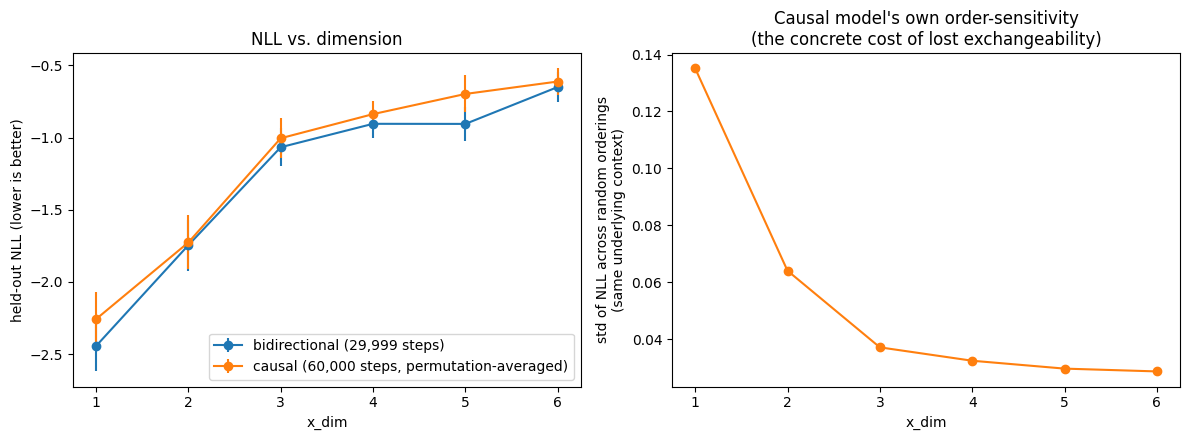

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

bidir_means = [results[d]["bidir_nll"].mean().item() for d in DIMS]
bidir_ses = [results[d]["bidir_nll"].std().item() / N_FUNCTIONS**0.5 for d in DIMS]
causal_means = [results[d]["causal_nll"].mean().item() for d in DIMS]
causal_ses = [results[d]["causal_nll"].std().item() / N_FUNCTIONS**0.5 for d in DIMS]

ax1.errorbar(DIMS, bidir_means, yerr=bidir_ses, marker="o", label="bidirectional (29,999 steps)")
ax1.errorbar(DIMS, causal_means, yerr=causal_ses, marker="o", label="causal (60,000 steps, permutation-averaged)")
ax1.set_xlabel("x_dim")
ax1.set_ylabel("held-out NLL (lower is better)")
ax1.set_title("NLL vs. dimension")
ax1.legend()

order_std_means = [results[d]["causal_order_std"].mean().item() for d in DIMS]
ax2.plot(DIMS, order_std_means, marker="o", color="tab:orange")
ax2.set_xlabel("x_dim")
ax2.set_ylabel("std of NLL across random orderings\n(same underlying context)")
ax2.set_title("Causal model's own order-sensitivity\n(the concrete cost of lost exchangeability)")

plt.tight_layout()
plt.show()

## Reading this

- The left panel is the actual quality comparison, order-fairly-averaged
  for the causal model per the reasoning above.
- The right panel isolates something the left panel can't show: *how much*
  does presentation order alone move the causal model's own predictions,
  independent of which model is "better." If this is large, it's a direct,
  concrete demonstration of what giving up exchangeability costs — and a
  reason to care about *which* order an acquisition policy would actually
  present points in, not just the model's average-case number.